## Импорт нужных библиотек

In [1]:
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as transforms
import tqdm
import matplotlib.pyplot as plt
from torchvision import models

## Определение трансформаций

In [2]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

## Класс датасет для данных

In [3]:
class PneumoniaDataset(Dataset):
    def __init__(self, image_dir="data/", transform=None):
        self.dir = image_dir
        self.transform = transform

        self.image_paths = []
        self.labels = []
        self.classes = sorted([d for d in os.listdir(self.dir) if os.path.isdir(os.path.join(self.dir, d))])
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}

        for class_name in self.classes:
            class_path = os.path.join(self.dir, class_name)
            for img_name in os.listdir(class_path):
                if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                    self.image_paths.append(os.path.join(class_path, img_name))
                    self.labels.append(self.class_to_idx[class_name])
    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('L')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

## Загрузка данных

In [4]:
DATA_PATH = "../data/"

train_dataset = PneumoniaDataset(
    image_dir=os.path.join(DATA_PATH, "train"),
    transform=train_transform
)

val_dataset = PneumoniaDataset(
    image_dir=os.path.join(DATA_PATH, "val"),
    transform=val_test_transform
)

test_dataset = PneumoniaDataset(
    image_dir=os.path.join(DATA_PATH, "test"),
    transform=val_test_transform
)

In [5]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

In [6]:
print(f"Train: {len(train_dataset)} images")
print(f"Val:   {len(val_dataset)} images")
print(f"Test:  {len(test_dataset)} images")
print(f"Classes: {train_dataset.classes}")

Train: 4541 images
Val:   691 images
Test:  624 images
Classes: ['NORMAL', 'PNEUMONIA']


## Визуализация нескольких трансформированных экземпляров

C:\Users\Aidarchik\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


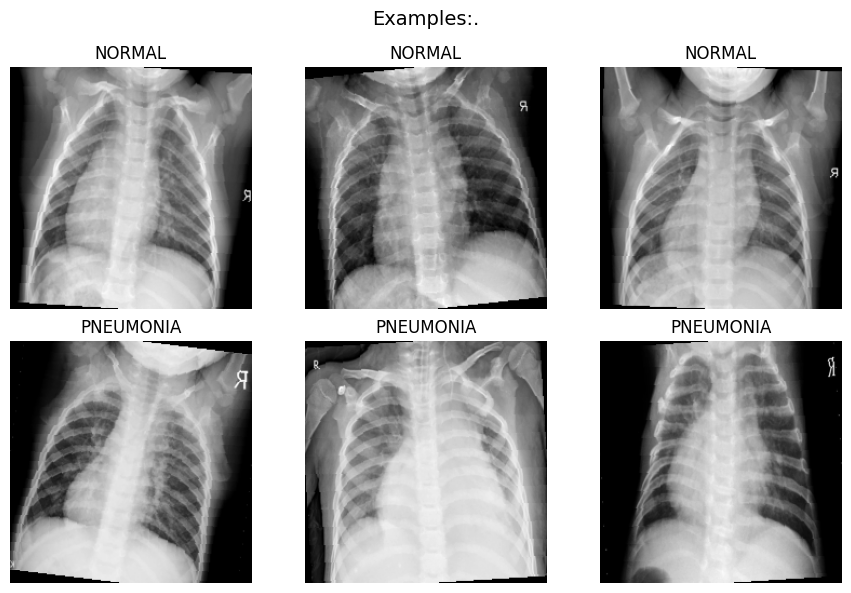

In [7]:
def show_samples(dataloader, samples=3):
    class_names = dataloader.dataset.classes
    class_samples = {name: [] for name in class_names}

    for images, labels in dataloader:
        for img, label in zip(images, labels):
            class_name = class_names[label.item()]
            if len(class_samples[class_name]) < samples:
                class_samples[class_name].append(img)

        if all(len(v) >= samples for v in class_samples.values()):
            break

    fig, axes = plt.subplots(len(class_names), samples, figsize=(samples*3, len(class_names)*3))

    if len(class_names) == 1:
        axes = [axes]

    for i, class_name in enumerate(class_names):
        for j in range(samples):
            img = class_samples[class_name][j][0].cpu().numpy()  # [1, H, W] → [H, W]
            axes[i, j].imshow(img, cmap='gray')
            axes[i, j].set_title(f'{class_name}')
            axes[i, j].axis('off')

    plt.suptitle('Examples:.', fontsize=14)
    plt.tight_layout()
    plt.show()

show_samples(train_loader, samples=3)

## Модель ResNet34 с измененными полносвязными слоями

In [8]:
def create_model():
    resnet_weights = models.ResNet34_Weights.DEFAULT
    model = models.resnet34(weights=resnet_weights)

    model.requires_grad_(False)

    model.fc = nn.Sequential(
        nn.Linear(512, 128, bias=True),
        nn.ReLU(inplace=True),
        nn.Dropout(0.4),
        nn.Linear(128, 2, bias=True)
    )

    model.fc.requires_grad_(True)

    class ModelWithAdapter(nn.Module):
        def __init__(self, backbone):
            super().__init__()
            self.adapter = nn.Conv2d(1, 3, kernel_size=1)
            self.backbone = backbone

        def forward(self, x):
            x = self.adapter(x)
            return self.backbone(x)

    return ModelWithAdapter(model)

In [9]:
model = create_model()

## Обучение модели

In [10]:
def train_epoch(epochs, train_data, val_data, loss_function, optimizer, device):
    best_val_acc = 0
    best_model_path = "../models/best_model.pth"

    for _e in range(epochs):
        model.train()
        loss_mean = 0
        lm_count = 0
        train_correct = 0
        train_total = 0

        train_tqdm = tqdm.tqdm(train_data, leave=True)
        for x_train, y_train in train_tqdm:
            x_train, y_train = x_train.to(device), y_train.to(device)

            predict = model(x_train)
            loss = loss_function(predict, y_train)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            lm_count += 1
            loss_mean = 1/lm_count * loss.item() + (1 - 1/lm_count) * loss_mean

            _, predicted = predict.max(1)
            train_total += y_train.size(0)
            train_correct += predicted.eq(y_train).sum().item()

            train_tqdm.set_description(
                f"Epoch [{_e+1}/{epochs}] Train | loss={loss_mean:.4f} | acc={100.*train_correct/train_total:.2f}%"
            )

        train_acc = 100. * train_correct / train_total

        model.eval()
        val_loss = 0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            val_tqdm = tqdm.tqdm(val_data, leave=True)
            for x_val, y_val in val_tqdm:
                x_val, y_val = x_val.to(device), y_val.to(device)

                predict = model(x_val)
                loss = loss_function(predict, y_val)

                val_loss += loss.item()
                _, predicted = predict.max(1)
                val_total += y_val.size(0)
                val_correct += predicted.eq(y_val).sum().item()

                val_tqdm.set_description(
                    f"Epoch [{_e+1}/{epochs}] Val   | acc={100.*val_correct/val_total:.2f}%"
                )

        val_loss = val_loss / len(val_data)
        val_acc = 100. * val_correct / val_total

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), best_model_path)
            print(f"The best model saved: {best_val_acc:.2f}%")

        print(f"   Train Loss: {loss_mean:.4f}, Train Acc: {train_acc:.2f}%")
        print(f"   Val Loss:   {val_loss:.4f}, Val Acc:   {val_acc:.2f}%")
        print("-" * 50)

    print(f"\nThe best accuracy on validation: {best_val_acc:.2f}%")
    return best_val_acc

In [11]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_func = nn.CrossEntropyLoss()
device = "cpu"

In [12]:
train_epoch(
    epochs=5,
    train_data=train_loader,
    val_data=val_loader,
    loss_function=loss_func,
    optimizer=optimizer,
    device=device
)

Epoch [1/5] Train | loss=0.2737 | acc=88.17%: 100%|██████████| 142/142 [12:31<00:00,  5.29s/it]
Epoch [1/5] Val   | acc=91.90%: 100%|██████████| 22/22 [00:57<00:00,  2.63s/it]


The best model saved: 91.90%
   Train Loss: 0.2737, Train Acc: 88.17%
   Val Loss:   0.2026, Val Acc:   91.90%
--------------------------------------------------


Epoch [2/5] Train | loss=0.2016 | acc=91.83%: 100%|██████████| 142/142 [12:36<00:00,  5.33s/it]
Epoch [2/5] Val   | acc=84.52%: 100%|██████████| 22/22 [00:56<00:00,  2.58s/it]


   Train Loss: 0.2016, Train Acc: 91.83%
   Val Loss:   0.3574, Val Acc:   84.52%
--------------------------------------------------


Epoch [3/5] Train | loss=0.1664 | acc=93.53%: 100%|██████████| 142/142 [12:33<00:00,  5.30s/it]
Epoch [3/5] Val   | acc=89.00%: 100%|██████████| 22/22 [00:56<00:00,  2.59s/it]


...

Epoch [4/5] Train | loss=0.1549 | acc=93.97%: 100%|██████████| 142/142 [11:44<00:00,  4.96s/it]
Epoch [4/5] Val   | acc=89.29%: 100%|██████████| 22/22 [00:45<00:00,  2.09s/it]


   Train Loss: 0.1549, Train Acc: 93.97%
   Val Loss:   0.2490, Val Acc:   89.29%
--------------------------------------------------


Epoch [5/5] Train | loss=0.1464 | acc=94.05%: 100%|██████████| 142/142 [10:02<00:00,  4.24s/it]
Epoch [5/5] Val   | acc=92.47%: 100%|██████████| 22/22 [00:45<00:00,  2.07s/it]

The best model saved: 92.47%
   Train Loss: 0.1464, Train Acc: 94.05%
   Val Loss:   0.1743, Val Acc:   92.47%
--------------------------------------------------

The best accuracy on validation: 92.47%


92.47467438494935

## Тест

In [13]:
model.load_state_dict(torch.load("../models/best_model.pth"))

model.eval()

test_correct = 0
test_total = 0

with torch.no_grad():
    for x_test, y_test in test_loader:
        x_test, y_test = x_test.to(device), y_test.to(device)
        predict = model(x_test)
        _, predicted = predict.max(1)
        test_total += y_test.size(0)
        test_correct += predicted.eq(y_test).sum().item()

test_acc = 100. * test_correct / test_total
print(f"Test accuracy: {test_acc:.2f}%")

Test accuracy: 83.65%


## Итог
Модель успешно детектирует пневмонию на рентгеновских снимках с точностью ~84% на тестовой выборке. Результат подтверждает эффективность Transfer Learning в медицинской диагностике даже при ограниченном объеме данных.